# RQ2: The Grid. Does qualifying predict the race?

**Question.** How strongly does starting grid position predict final finishing position, and does the relationship differ between street circuits and permanent circuits?

This is the prototyping notebook for Chapter 2 of the ship product at https://f1-info-viz.vercel.app/. We work through 25,238 individual race entries spanning 1950 to 2026, looking at the link between Saturday qualifying and Sunday's result.

**Approach.** Compute Pearson correlation coefficients between grid and finish position, both overall and split by circuit type, updated live for user-selected subsets in the ship app. Track position change (`finish - grid`) as a secondary signal for how much overtaking a circuit actually allows. Circuits are classified as Street vs Permanent by a keyword rule in the data pipeline: any circuit name containing "Monaco", "Baku", "Las Vegas", "Singapore", "Jeddah", "Miami" or "Street" is tagged Street; everything else defaults to Permanent. The shipped scatter uses low per-point opacity so the cluster density becomes the visual signal.

**Dataset.** `rq2_grid_finish_circuits.csv`, one row per driver-race entry with grid, finish, circuit, constructor and year.

**EDA notebook:** see `data_EDA.ipynb`. External EDA link: TBD.

In [1]:
import plotly.io as pio
pio.renderers.default = 'png'
pio.kaleido.scope.default_width = 900
pio.kaleido.scope.default_height = 520
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

pd.set_option('display.max_rows', 100)

df = pd.read_csv('../final_datasets/rq2_grid_finish_circuits.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_67789/2972423914.py:3: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  pio.kaleido.scope.default_width = 900
/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_67789/2972423914.py:4: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  pio.kaleido.scope.default_height = 520


Shape: (25238, 10)

Column types:
Year                 int64
Race Name              str
Circuit Name           str
Driver                 str
Constructor            str
Grid Position      float64
Finish Position    float64
Points             float64
Dataset                str
Circuit Type           str
dtype: object

First 5 rows:


,Year,Race Name,Circuit Name,Driver,Constructor,Grid Position,Finish Position,Points,Dataset,Circuit Type
0,2008,Australian GP,Albert Park Grand Prix Circuit,Lewis Hamilton,McLaren,1.0,1.0,10.0,Historical (1950-2017),Street Circuit
1,2008,Australian GP,Albert Park Grand Prix Circuit,Nick Heidfeld,Sauber,5.0,2.0,8.0,Historical (1950-2017),Street Circuit
2,2008,Australian GP,Albert Park Grand Prix Circuit,Nico Rosberg,Williams,7.0,3.0,6.0,Historical (1950-2017),Street Circuit
3,2008,Australian GP,Albert Park Grand Prix Circuit,Fernando Alonso,Renault,11.0,4.0,5.0,Historical (1950-2017),Street Circuit
4,2008,Australian GP,Albert Park Grand Prix Circuit,Heikki Kovalainen,McLaren,3.0,5.0,4.0,Historical (1950-2017),Street Circuit


## 1. Data Quality Check

In [2]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nYear range: {df['Year'].min()} – {df['Year'].max()}")
print(f"Unique drivers: {df['Driver'].nunique()}")
print(f"Unique tracks (Race Name): {df['Race Name'].nunique()}")
print(f"\nCircuit Type distribution:")
print(df['Circuit Type'].value_counts())

Missing values per column:
Year               0
Race Name          0
Circuit Name       0
Driver             0
Constructor        0
Grid Position      0
Finish Position    0
Points             0
Dataset            0
Circuit Type       0
dtype: int64

Duplicate rows: 0

Year range: 1950 – 2026
Unique drivers: 799
Unique tracks (Race Name): 46

Circuit Type distribution:
Circuit Type
Permanent Circuit    22289
Street Circuit        2949
Name: count, dtype: int64


## 2. Descriptive Statistics

In [3]:
print("Descriptive statistics:\n")
df[['Grid Position', 'Finish Position', 'Points']].describe().round(2)

Descriptive statistics:



,Grid Position,Finish Position,Points
count,25238.00,25238.00,25238.00
mean,11.86,11.72,2.21
std,6.85,6.80,4.57
min,1.00,1.00,0.00
25%,6.00,6.00,0.00
50%,12.00,11.00,0.00
75%,17.00,17.00,2.00
max,71.00,34.00,50.00


## 3. Position change

Quick derived column: `Position Change = Finish - Grid`. Negative means the driver gained places; positive means they lost them. Across 24,956 valid entries the overall correlation between grid and finish lands at r = 0.452, with permanent circuits at r = 0.454 and street circuits at r = 0.437. The two numbers look almost identical, but the *shape* of the distributions is very different, and that is where the chapter's insight lives. The next few charts unpack it.

In [4]:
# Filter valid entries (drops invalid rows)
valid = df[(df['Grid Position'] > 0) & (df['Finish Position'] > 0) &
           (df['Grid Position'] <= 26) & (df['Finish Position'] <= 26)].copy()

valid['Position Change'] = valid['Finish Position'] - valid['Grid Position']

print(f"Valid entries: {len(valid)} out of {len(df)}")
print(f"\nCorrelation (Grid vs Finish):")
print(f"  Overall:   r = {valid['Grid Position'].corr(valid['Finish Position']):.4f}")
print(f"  Street:    r = {valid[valid['Circuit Type'] == 'Street Circuit']['Grid Position'].corr(valid[valid['Circuit Type'] == 'Street Circuit']['Finish Position']):.4f}")
print(f"  Permanent: r = {valid[valid['Circuit Type'] == 'Permanent Circuit']['Grid Position'].corr(valid[valid['Circuit Type'] == 'Permanent Circuit']['Finish Position']):.4f}")

print(f"\nPosition change stats:")
valid['Position Change'].describe().round(2)

Valid entries: 24956 out of 25238

Correlation (Grid vs Finish):
  Overall:   r = 0.4524
  Street:    r = 0.4371
  Permanent: r = 0.4542

Position change stats:


count    24956.00
mean        -0.13
std          7.00
min        -23.00
25%         -4.00
50%         -1.00
75%          3.00
max         25.00
Name: Position Change, dtype: float64

---

## Visualization prototyping

## 4. Grid and finish distributions

Side-by-side histograms confirm the data is clean. Both distributions are broadly uniform across grid slots 1 through ~20, with a small tail for lapped and retired cars. Nothing surprising here. It is a sanity check before moving to the joint distribution.

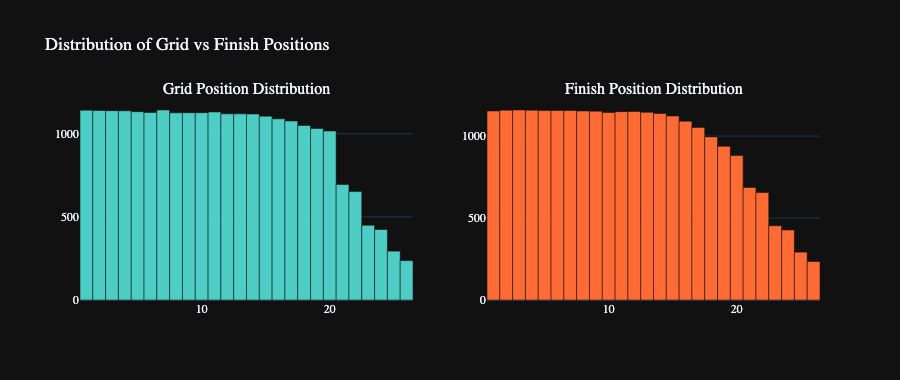

In [5]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Grid Position Distribution', 'Finish Position Distribution'))

fig.add_trace(go.Histogram(
    x=valid['Grid Position'], nbinsx=26,
    marker_color='#4ecdc4', marker_line_color='#0a0a0a', marker_line_width=0.5,
    name='Grid'
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=valid['Finish Position'], nbinsx=26,
    marker_color='#ff6b35', marker_line_color='#0a0a0a', marker_line_width=0.5,
    name='Finish'
), row=1, col=2)

fig.update_layout(
    title='Distribution of Grid vs Finish Positions',
    template='plotly_dark', height=380,
    font=dict(family='DM Sans'), title_font_size=18,
    showlegend=False
)
fig.show()

## 5. Position change distribution

Histogram of `finish - grid`, overlaid by circuit type. Symmetry around zero is expected (someone has to lose a place for someone else to gain one), but the two distributions pile up at different rates. Street circuits peak tighter and drop off faster at the tails; permanent circuits spread wider. This is the first visible hint that the "same r value" hides two different stories.

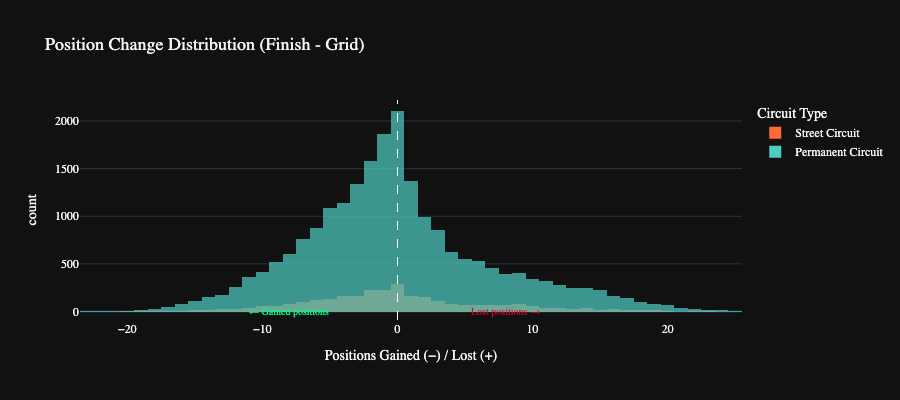

In [6]:
fig = px.histogram(
    valid, x='Position Change', nbins=50,
    color='Circuit Type',
    color_discrete_map={'Street Circuit': '#ff6b35', 'Permanent Circuit': '#4ecdc4'},
    barmode='overlay',
    title='Position Change Distribution (Finish - Grid)',
    labels={'Position Change': 'Positions Gained (−) / Lost (+)'},
    template='plotly_dark', opacity=0.7
)
fig.add_vline(x=0, line_dash='dash', line_color='white', line_width=1)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=400,
    annotations=[dict(
        x=-8, y=0, xref='x', yref='y',
        text='← Gained positions', showarrow=False,
        font=dict(size=10, color='#00ff87')
    ), dict(
        x=8, y=0, xref='x', yref='y',
        text='Lost positions →', showarrow=False,
        font=dict(size=10, color='#e8002d')
    )]
)
fig.show()

## 6. Raw scatter, grid vs finish

First pass: every race entry plotted, low opacity, with a `y = x` dashed reference line. Points above the line are drivers who lost places; points below are drivers who gained. The diagonal stripe of density is already visible before any splits or regressions are added.

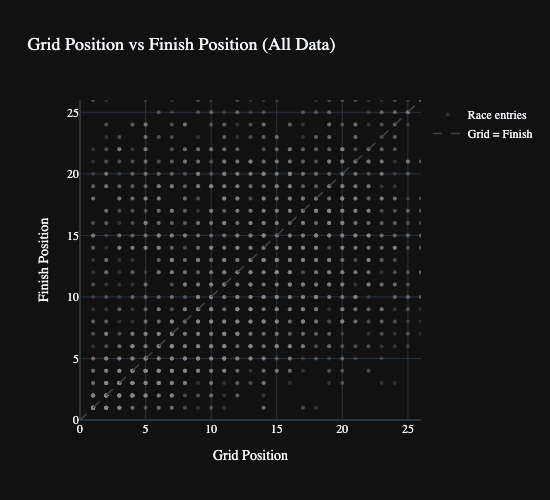

In [7]:
# Sample for performance (keeps chart responsive)
sample = valid.sample(n=min(3000, len(valid)), random_state=42)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sample['Grid Position'], y=sample['Finish Position'],
    mode='markers',
    marker=dict(size=4, color='#888888', opacity=0.3),
    name='Race entries'
))

# Diagonal reference
fig.add_trace(go.Scatter(
    x=[0, 26], y=[0, 26],
    mode='lines',
    line=dict(dash='dash', color='#444444', width=1.5),
    name='Grid = Finish',
    showlegend=True
))

fig.update_layout(
    title='Grid Position vs Finish Position (All Data)',
    xaxis_title='Grid Position', yaxis_title='Finish Position',
    xaxis=dict(range=[0, 26]), yaxis=dict(range=[0, 26]),
    template='plotly_dark', height=500, width=550,
    font=dict(family='DM Sans'), title_font_size=18,
)
fig.show()

## 7. Scatter colored by circuit type

Splitting by circuit type reveals the core insight. Orange (street) clusters tighter against the diagonal than teal (permanent). On permanent circuits, long straights and DRS zones give genuine overtaking opportunities: Spa, Monza, Silverstone, Suzuka, Interlagos. On street circuits, the walls are the walls, and most drivers finish near where they started. Baku, Jeddah and Singapore follow the same pattern at different severities; Monaco is the extreme.

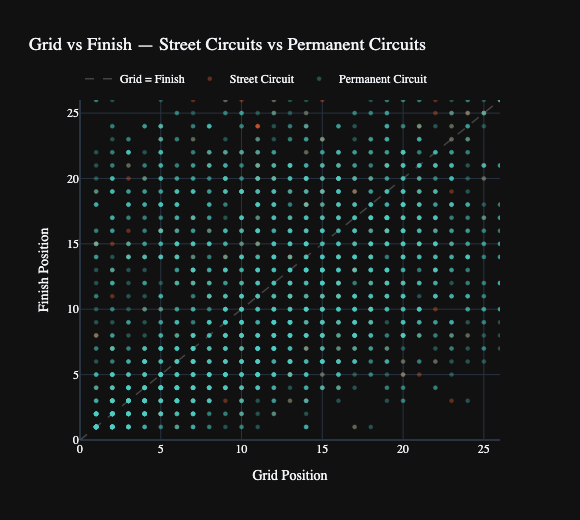

In [8]:
STREET_COLOR = '#ff6b35'
PERMANENT_COLOR = '#4ecdc4'

fig = go.Figure()

# Diagonal reference
fig.add_trace(go.Scatter(
    x=[0, 26], y=[0, 26], mode='lines',
    line=dict(dash='dash', color='#444444', width=1.5),
    name='Grid = Finish'
))

for ct, color in [('Street Circuit', STREET_COLOR), ('Permanent Circuit', PERMANENT_COLOR)]:
    subset = sample[sample['Circuit Type'] == ct]
    fig.add_trace(go.Scatter(
        x=subset['Grid Position'], y=subset['Finish Position'],
        mode='markers', name=ct,
        marker=dict(size=4, color=color, opacity=0.35,
                    line=dict(color=color, width=0.5)),
    ))

fig.update_layout(
    title='Grid vs Finish : Street Circuits vs Permanent Circuits',
    xaxis_title='Grid Position', yaxis_title='Finish Position',
    xaxis=dict(range=[0, 26]), yaxis=dict(range=[0, 26]),
    template='plotly_dark', height=520, width=580,
    font=dict(family='DM Sans'), title_font_size=18,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

## 8. Scatter with regression overlays

Same scatter with an OLS regression line per circuit type. The r values (0.454 permanent, 0.437 street) print on the legend and update live in the app as users change filters. The regression slopes land almost on top of each other, which is why the real takeaway is about distribution *shape*, not mean slope: on street circuits more drivers cluster close to the diagonal, but the ones who slip tend to slip catastrophically (leptokurtic: narrow peak, heavy tails). Hit a wall at Monaco and you are out; there is no gravel trap to save the car.

In [ ]:
fig = go.Figure()

# Diagonal
fig.add_trace(go.Scatter(
    x=[0, 26], y=[0, 26], mode='lines',
    line=dict(dash='dash', color='#444444', width=1.5),
    name='Grid = Finish', showlegend=True
))

for ct, color in [('Street Circuit', STREET_COLOR), ('Permanent Circuit', PERMANENT_COLOR)]:
    subset = valid[valid['Circuit Type'] == ct]
    sample_ct = subset.sample(n=min(1500, len(subset)), random_state=42)
    
    # Scatter
    fig.add_trace(go.Scatter(
        x=sample_ct['Grid Position'], y=sample_ct['Finish Position'],
        mode='markers', name=ct,
        marker=dict(size=4, color=color, opacity=0.25),
    ))
    
    # Regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        subset['Grid Position'], subset['Finish Position']
    )
    x_reg = np.array([1, 24])
    y_reg = slope * x_reg + intercept
    
    fig.add_trace(go.Scatter(
        x=x_reg, y=y_reg, mode='lines',
        line=dict(color=color, width=3),
        name=f'{ct} (r = {r_value:.3f})',
    ))

fig.update_layout(
    title='Grid vs Finish with Regression: Street vs Permanent',
    xaxis_title='Grid Position', yaxis_title='Finish Position',
    xaxis=dict(range=[0, 26]), yaxis=dict(range=[0, 26]),
    template='plotly_dark', height=540, width=600,
    font=dict(family='DM Sans'), title_font_size=18,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

## 9. 2D density heatmap

With 25k points the scatter overlaps heavily even at 25% opacity. Binning into a 26x26 grid and coloring by frequency shows the true joint density. The diagonal is brightest for P1-P6 (front-runners tend to stay in front) and fades through the midfield, where a single mechanical or strategic decision can drop a driver five or six places. The top-right corner is also dense: backmarkers tend to stay backmarkers.

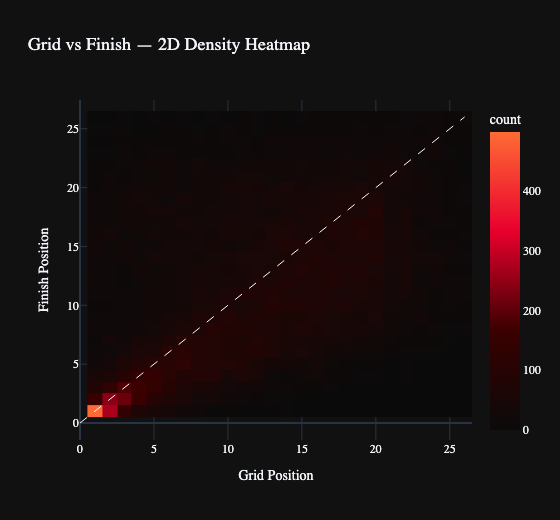

In [10]:
fig = px.density_heatmap(
    valid, x='Grid Position', y='Finish Position',
    nbinsx=26, nbinsy=26,
    color_continuous_scale=['#0a0a0a', '#3a0000', '#e8002d', '#ff6b35'],
    title='Grid vs Finish : 2D Density Heatmap',
    template='plotly_dark'
)

# Add diagonal reference
fig.add_trace(go.Scatter(
    x=list(range(0, 27)), y=list(range(0, 27)),
    mode='lines', line=dict(dash='dash', color='white', width=1),
    showlegend=False
))

fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=520, width=560,
    xaxis_title='Grid Position', yaxis_title='Finish Position',
)
fig.show()

## 10. Pole-to-win conversion

What fraction of pole sitters actually win the race. Split three ways: all street circuits, all permanent circuits, and Monaco specifically. Monaco pole is the single most valuable Saturday result in F1 because overtaking rates approach zero. If you lead after lap 1, you tend to lead at the flag.

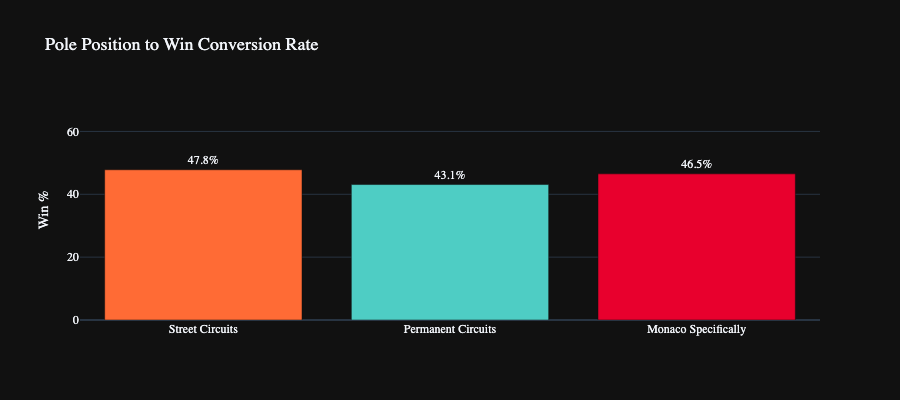


Detailed stats:


,Category,Pole-to-Win %,Total Poles
0,Street Circuits,47.8,136
1,Permanent Circuits,43.1,1006
2,Monaco Specifically,46.5,71


In [11]:
pole_sitters = valid[valid['Grid Position'] == 1]

street_pole = pole_sitters[pole_sitters['Circuit Type'] == 'Street Circuit']
perm_pole = pole_sitters[pole_sitters['Circuit Type'] == 'Permanent Circuit']
monaco_pole = pole_sitters[pole_sitters['Race Name'].str.contains('Monaco', na=False)]

street_win = (street_pole['Finish Position'] == 1).sum() / len(street_pole) * 100
perm_win = (perm_pole['Finish Position'] == 1).sum() / len(perm_pole) * 100
monaco_win = (monaco_pole['Finish Position'] == 1).sum() / len(monaco_pole) * 100

stats_data = pd.DataFrame({
    'Category': ['Street Circuits', 'Permanent Circuits', 'Monaco Specifically'],
    'Pole-to-Win %': [round(street_win, 1), round(perm_win, 1), round(monaco_win, 1)],
    'Total Poles': [len(street_pole), len(perm_pole), len(monaco_pole)]
})

fig = go.Figure(go.Bar(
    x=stats_data['Category'],
    y=stats_data['Pole-to-Win %'],
    marker_color=[STREET_COLOR, PERMANENT_COLOR, '#e8002d'],
    text=stats_data['Pole-to-Win %'].astype(str) + '%',
    textposition='outside'
))
fig.update_layout(
    title='Pole Position to Win Conversion Rate',
    yaxis_title='Win %', yaxis=dict(range=[0, 70]),
    template='plotly_dark', height=400,
    font=dict(family='DM Sans'), title_font_size=18,
)
fig.show()

print("\nDetailed stats:")
stats_data

## 11. Monaco 2024 spotlight

The cleanest recent example of grid-equals-finish. At Monaco 2024 the top 10 qualifiers finished in their exact qualifying order. Charles Leclerc converted pole into a home win, and every position behind him (Piastri, Sainz, Norris, Russell, Verstappen, Hamilton, Tsunoda, Alonso, Gasly) held station from lap 1 to the flag. A lap-1 crash neutralized tire strategy, safety-car windows collapsed, and on a circuit this narrow there simply was not room to pass. We highlight this in the ship app with a red circle annotation as the limiting case: when r between grid and finish approaches 1.0 and overtaking goes to zero, the race is effectively won on Saturday. Nelson Piquet's old quip about Monaco ("like riding a bicycle around your living room") captures the geometry perfectly.

Monaco 2024 entries: 16
Entries where Grid == Finish: 12



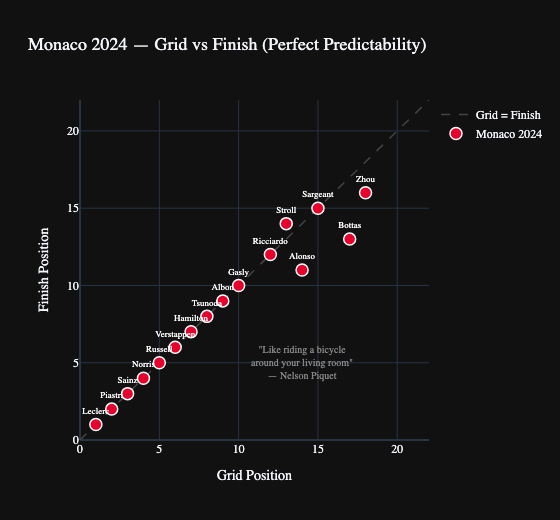

,Driver,Grid Position,Finish Position,Position Change
24494,Charles Leclerc,1.0,1.0,0.0
24495,Oscar Piastri,2.0,2.0,0.0
24496,Carlos Sainz,3.0,3.0,0.0
24497,Lando Norris,4.0,4.0,0.0
24498,George Russell,5.0,5.0,0.0
24499,Max Verstappen,6.0,6.0,0.0
24500,Lewis Hamilton,7.0,7.0,0.0
24501,Yuki Tsunoda,8.0,8.0,0.0
24502,Alexander Albon,9.0,9.0,0.0
24503,Pierre Gasly,10.0,10.0,0.0


In [12]:
monaco24 = valid[(valid['Year'] == 2024) & (valid['Race Name'].str.contains('Monaco', na=False))]
print(f"Monaco 2024 entries: {len(monaco24)}")
print(f"Entries where Grid == Finish: {(monaco24['Grid Position'] == monaco24['Finish Position']).sum()}")
print()

fig = go.Figure()

# Diagonal
fig.add_trace(go.Scatter(
    x=[0, 22], y=[0, 22], mode='lines',
    line=dict(dash='dash', color='#444444', width=1.5),
    name='Grid = Finish'
))

# Monaco 2024 dots
fig.add_trace(go.Scatter(
    x=monaco24['Grid Position'], y=monaco24['Finish Position'],
    mode='markers+text',
    marker=dict(size=12, color='#e8002d', symbol='circle',
                line=dict(color='white', width=1.5)),
    text=monaco24['Driver'].apply(lambda x: x.split()[-1]),
    textposition='top center',
    textfont=dict(size=9, color='white'),
    name='Monaco 2024'
))

fig.update_layout(
    title='Monaco 2024 : Grid vs Finish (Perfect Predictability)',
    xaxis_title='Grid Position', yaxis_title='Finish Position',
    xaxis=dict(range=[0, 22]), yaxis=dict(range=[0, 22]),
    template='plotly_dark', height=520, width=560,
    font=dict(family='DM Sans'), title_font_size=18,
    annotations=[dict(
        x=14, y=5, text='"Like riding a bicycle<br>around your living room"<br>: Nelson Piquet',
        showarrow=False, font=dict(size=10, color='#888888', family='DM Sans'),
    )]
)
fig.show()

monaco24[['Driver', 'Grid Position', 'Finish Position', 'Position Change']].sort_values('Grid Position')

## 12. Violin by circuit type

Violin plots of position change split by circuit type. Street circuits show a taller, narrower violin centered at zero; permanent circuits are wider and flatter. Same means, different spreads. This is the distributional picture that the regression slopes in chart 8 were not able to capture on their own.

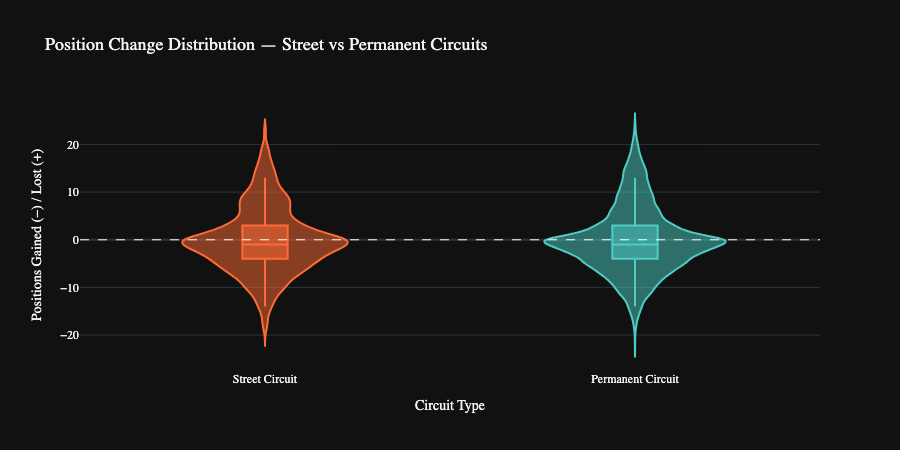

In [13]:
fig = px.violin(
    valid, x='Circuit Type', y='Position Change',
    color='Circuit Type',
    color_discrete_map={'Street Circuit': STREET_COLOR, 'Permanent Circuit': PERMANENT_COLOR},
    box=True, points=False,
    title='Position Change Distribution : Street vs Permanent Circuits',
    template='plotly_dark'
)
fig.add_hline(y=0, line_dash='dash', line_color='white', line_width=1)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=450,
    showlegend=False,
    yaxis_title='Positions Gained (−) / Lost (+)'
)
fig.show()

## 13. Per-track correlation

Pearson r computed per track (with a 50-entry minimum), colored by circuit type. Most predictable tracks sit at the top: Monaco, Jeddah, Singapore, Baku, all street, all confirming the thesis. Least predictable are the classic overtaking venues: Spa, Interlagos, the older Hockenheim layout, and the Nurburgring. A user-facing filter on the ship app lets readers re-sort this by year range to see which tracks have gotten more or less predictable as car and tire regulations change.

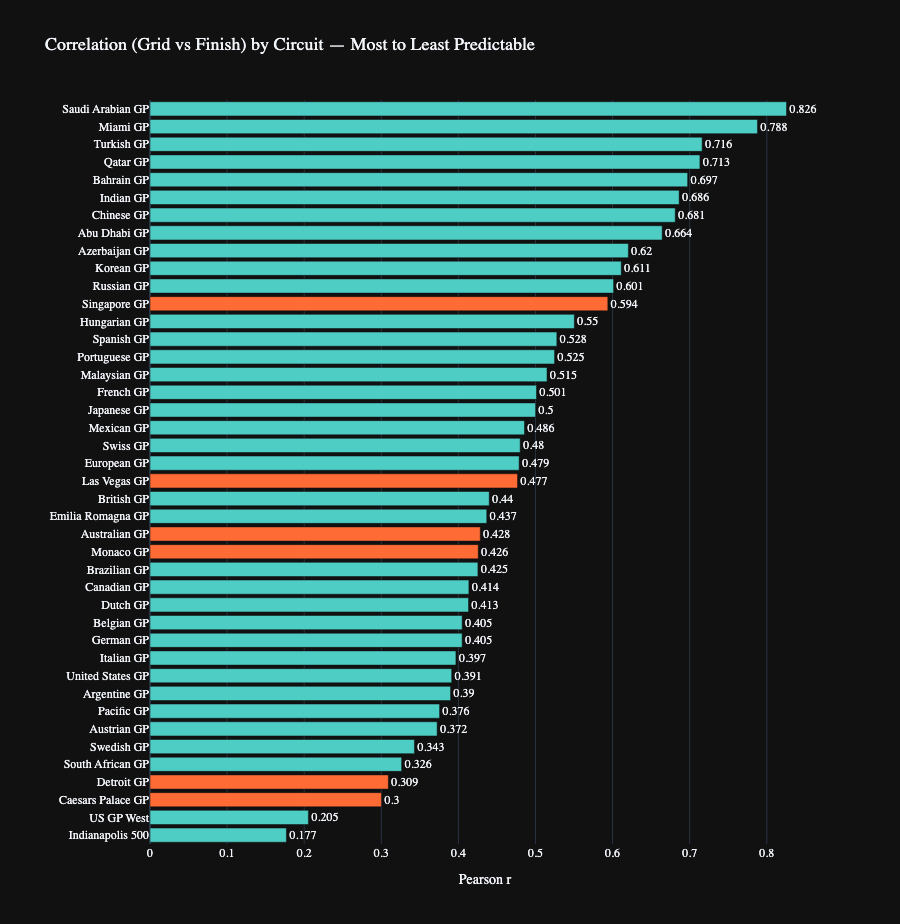

In [14]:
# Min 50 entries per track
track_corr = valid.groupby('Race Name').apply(
    lambda g: pd.Series({
        'r': g['Grid Position'].corr(g['Finish Position']),
        'entries': len(g),
        'circuit_type': g['Circuit Type'].mode().iloc[0] if len(g) > 0 else 'Unknown'
    })
).reset_index()
track_corr = track_corr[track_corr['entries'] >= 50].sort_values('r', ascending=True)

colors = [STREET_COLOR if ct == 'Street Circuit' else PERMANENT_COLOR 
          for ct in track_corr['circuit_type']]

fig = go.Figure(go.Bar(
    y=track_corr['Race Name'],
    x=track_corr['r'],
    orientation='h',
    marker_color=colors,
    text=track_corr['r'].round(3), textposition='outside'
))
fig.update_layout(
    title='Correlation (Grid vs Finish) by Circuit : Most to Least Predictable',
    xaxis_title='Pearson r', yaxis_title='',
    template='plotly_dark', height=max(400, len(track_corr) * 22),
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=150)
)
fig.show()

---

## Chapter 2 narrative: precision vs attrition

Two things to take away from this chapter:

1. **Qualifying matters everywhere, but it matters differently on streets.** The overall r = 0.452 says Saturday is a solid predictor of Sunday. The split (street r = 0.437, permanent r = 0.454) looks minor at first. But the distributions tell a sharper story. Permanent circuits produce a diffuse cloud: overtaking is possible, tire strategies pay off, and a mid-race safety car can reshuffle positions. Street circuits produce a leptokurtic cluster: most drivers finish within a slot of where they started, and the ones who fall fall hard. On a permanent circuit a bad start costs you a few places. On a street circuit it can cost you your car.
2. **Monaco is the limit case, and it is not an accident.** The pole-to-win conversion bar chart shows Monaco converting at a far higher rate than a generic permanent circuit. Monaco 2024 with ten drivers finishing in their exact grid order is what this chapter is really about: when the track geometry denies overtaking, the qualifying lap *is* the race.

What ships in the app: a filterable scatter with year and track controls, the circuit-type color split, live-updating regression overlays with r values recomputed per selection, and the Monaco 2024 highlight as an annotated red ring.